In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

movies = pd.read_pickle('artifacts/movies.pkl')
print("Loaded:", movies.shape)

Loaded: (4803, 9)


In [6]:
print(movies.columns.tolist())

['id', 'title', 'tags', 'budget', 'revenue', 'popularity', 'runtime', 'vote_average', 'vote_count']


In [7]:
print(movies.shape)
print(movies.dtypes)
movies.describe()

(4803, 9)
id                int64
title            object
tags             object
budget          float64
revenue         float64
popularity      float64
runtime         float64
vote_average    float64
vote_count        int64
dtype: object


,id,budget,revenue,popularity,runtime,vote_average,vote_count
count,4803.000000,4.803000e+03,4.803000e+03,4803.000000,4803.000000,4803.000000,4803.000000
mean,57165.484281,3.401089e+07,9.763642e+07,21.492301,106.874245,6.092172,690.217989
std,88694.614033,3.820157e+07,1.566898e+08,31.816650,22.607364,1.194612,1234.585891
min,5.000000,1.000000e+00,5.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,9014.500000,1.200000e+07,2.760697e+07,4.668070,94.000000,5.600000,54.000000
50%,14629.000000,2.300000e+07,5.175184e+07,12.921594,103.000000,6.200000,235.000000
75%,58610.500000,4.000000e+07,9.291719e+07,28.313505,117.500000,6.800000,737.000000
max,459488.000000,3.800000e+08,2.787965e+09,875.581305,338.000000,10.000000,13752.000000


C:\Users\MSI\AppData\Local\Temp\ipykernel_20684\2844208157.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=most_rated.values, y=most_rated.index, palette='viridis')


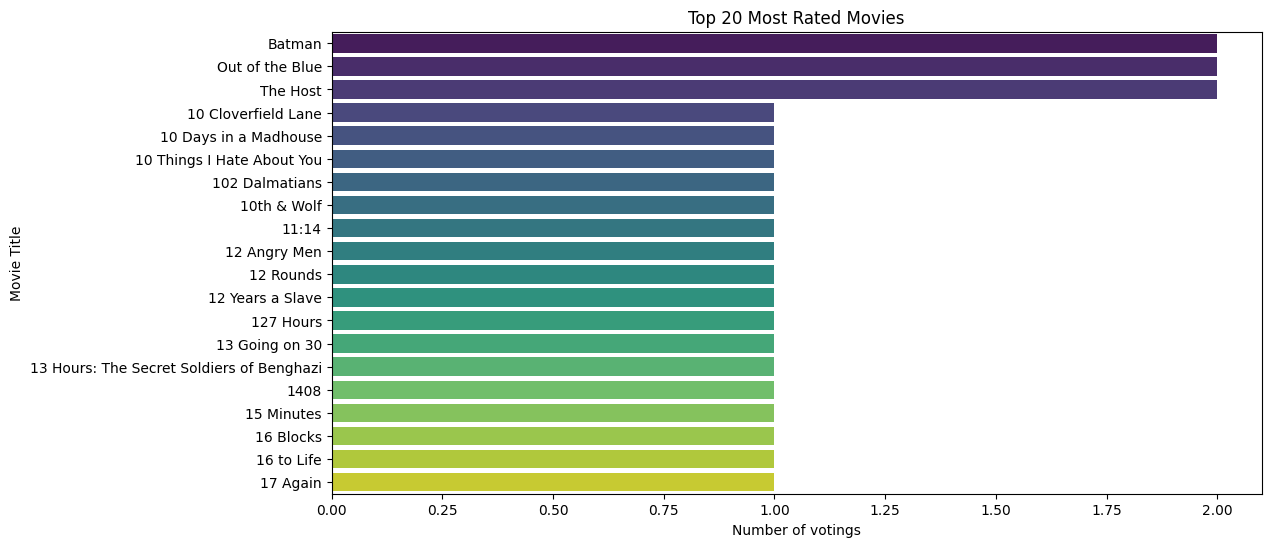

mean rating: 6.09 | median rating: 6.20 | std rating: 1.19


In [11]:
most_rated = movies.groupby('title')['vote_count'].count().sort_values(ascending=False).head(20)
plt.figure(figsize=(12, 6))
sns.barplot(x=most_rated.values, y=most_rated.index, palette='viridis')
plt.title('Top 20 Most Rated Movies')
plt.xlabel('Number of votings')
plt.ylabel('Movie Title')
plt.show()
print(f'mean rating: {movies["vote_average"].mean():.2f} | median rating: {movies["vote_average"].median():.2f} | std rating: {movies["vote_average"].std():.2f}')

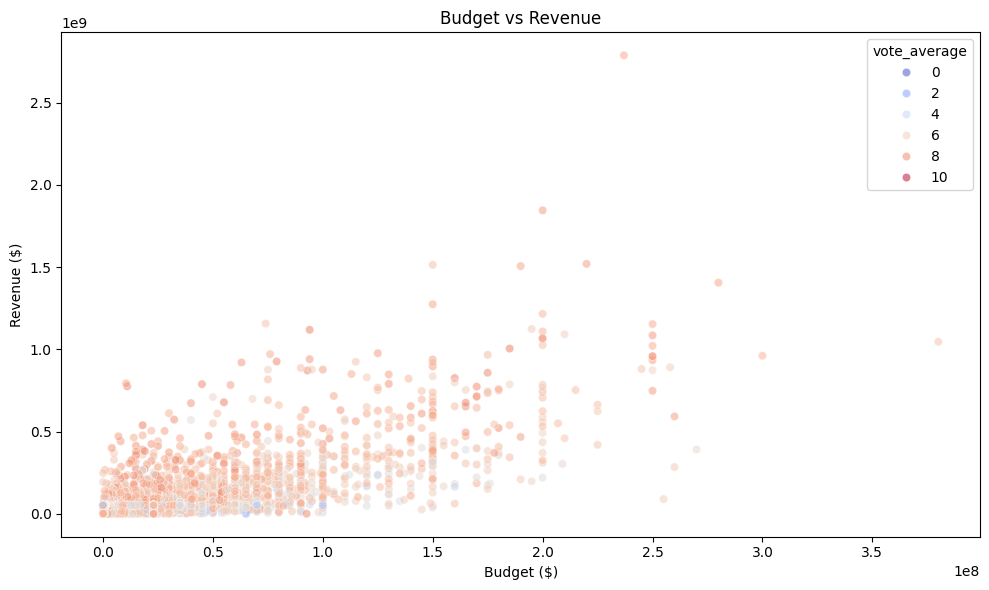

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=movies, x='budget', y='revenue',
                alpha=0.5, hue='vote_average', palette='coolwarm')
plt.title('Budget vs Revenue')
plt.xlabel('Budget ($)')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.show()

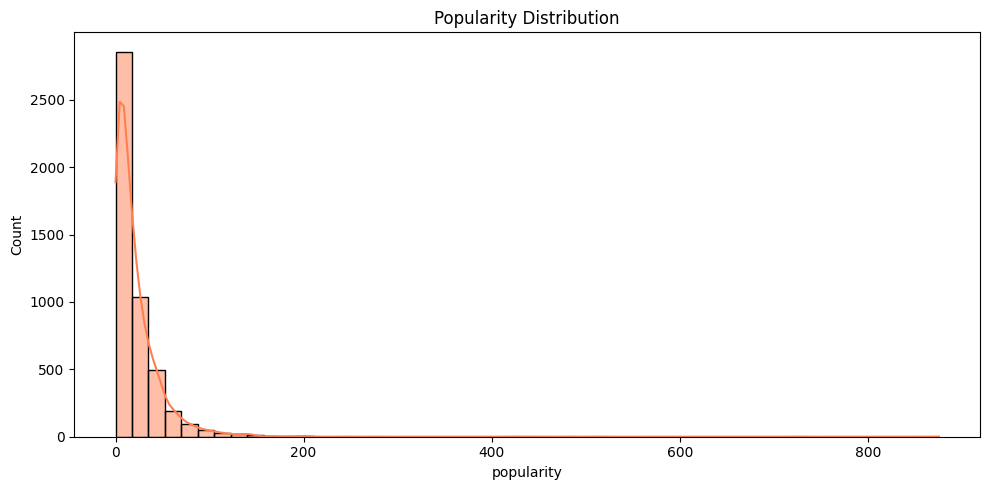

Most popular movie:
                       title  popularity
546                  Minions  875.581305
95              Interstellar  724.247784
788                 Deadpool  514.569956
94   Guardians of the Galaxy  481.098624
127       Mad Max: Fury Road  434.278564


In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(movies['popularity'], bins=50, kde=True, color='coral')
plt.title('Popularity Distribution')
plt.tight_layout()
plt.show()

print("Most popular movie:")
print(movies[['title', 'popularity']].sort_values('popularity', ascending=False).head(5))

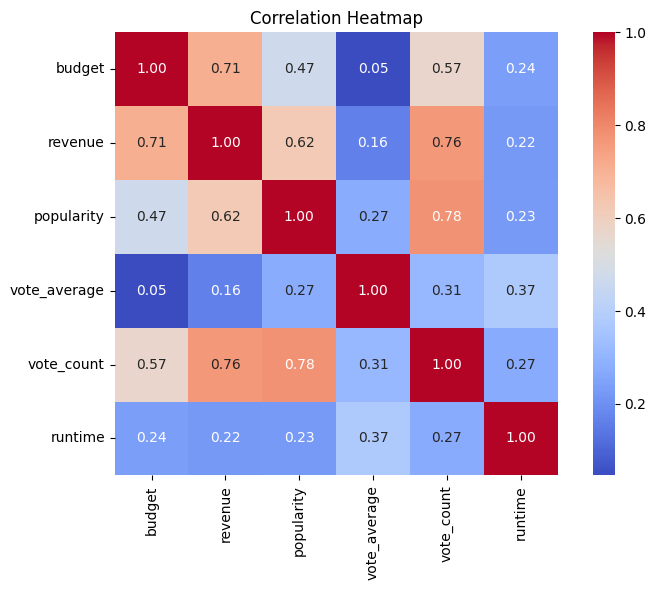

In [17]:
plt.figure(figsize=(8, 6))
corr_cols = ['budget', 'revenue', 'popularity', 'vote_average', 'vote_count', 'runtime']
sns.heatmap(movies[corr_cols].corr(),
            annot=True, fmt='.2f',
            cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

C:\Users\MSI\AppData\Local\Temp\ipykernel_20684\130114878.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='popularity', y='title', data=top10, palette='Blues_r')


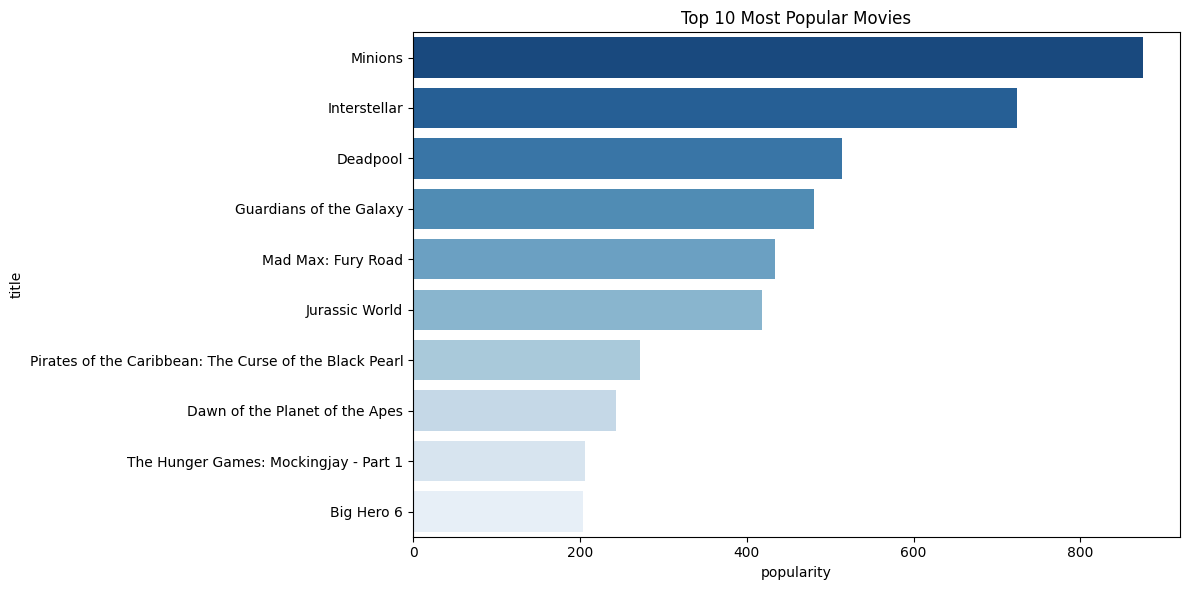

In [18]:
top10 = movies[['title', 'popularity', 'vote_average']]\
        .sort_values('popularity', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='popularity', y='title', data=top10, palette='Blues_r')
plt.title('Top 10 Most Popular Movies')
plt.tight_layout()
plt.show()

C:\Users\MSI\AppData\Local\Temp\ipykernel_20684\493856835.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='vote_average', y='title', data=top_rated, palette='Greens_r')


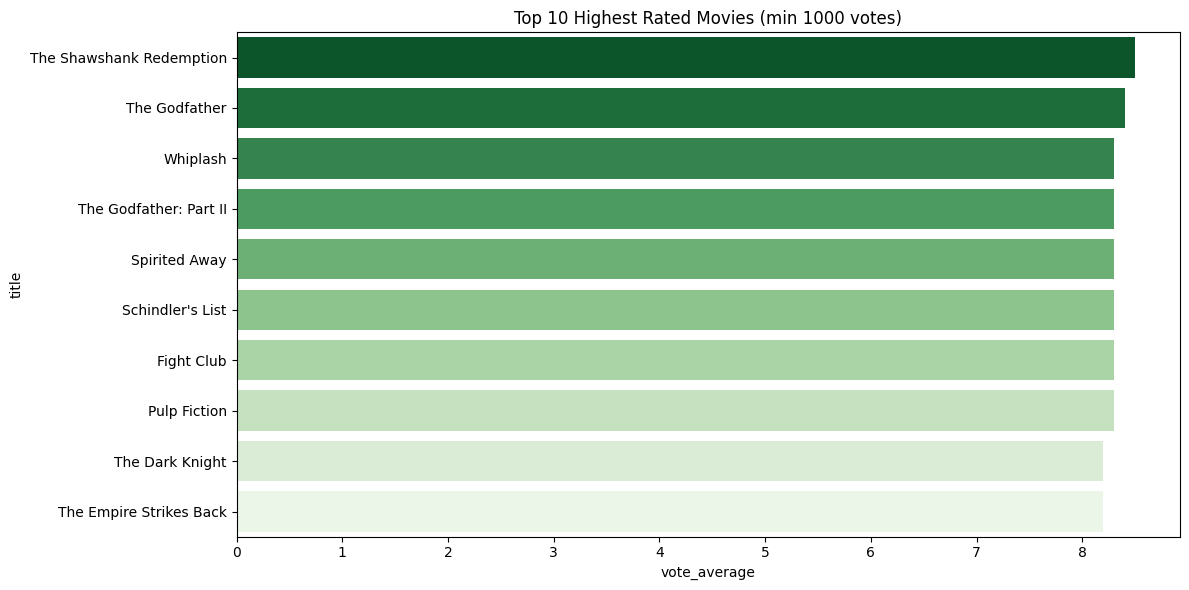

In [19]:
top_rated = movies[movies['vote_count'] > 1000][['title', 'vote_average', 'vote_count']]\
            .sort_values('vote_average', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='vote_average', y='title', data=top_rated, palette='Greens_r')
plt.title('Top 10 Highest Rated Movies (min 1000 votes)')
plt.tight_layout()
plt.show()

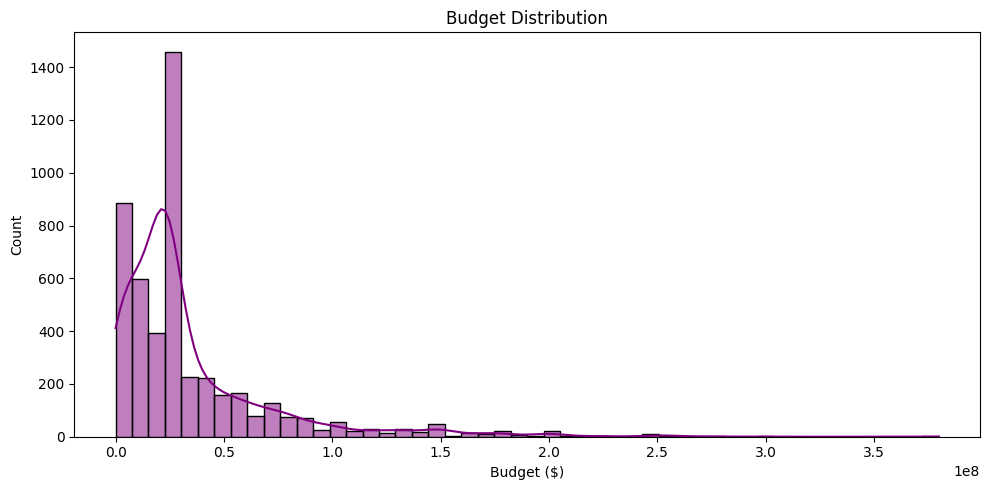

Highest budget movie:
                                          title       budget
17  Pirates of the Caribbean: On Stranger Tides  380000000.0
1      Pirates of the Caribbean: At World's End  300000000.0
7                       Avengers: Age of Ultron  280000000.0


In [20]:
plt.figure(figsize=(10, 5))
sns.histplot(movies['budget'], bins=50, kde=True, color='purple')
plt.title('Budget Distribution')
plt.xlabel('Budget ($)')
plt.tight_layout()
plt.show()

print("Highest budget movie:")
print(movies[['title', 'budget']].sort_values('budget', ascending=False).head(3))

In [21]:
print("=== DATASET SUMMARY ===")
print(f"Total movies:       {len(movies)}")
print(f"Avg vote average:   {movies['vote_average'].mean():.2f}")
print(f"Avg budget:         ${movies['budget'].mean():,.0f}")
print(f"Avg revenue:        ${movies['revenue'].mean():,.0f}")
print(f"Most popular:       {movies.loc[movies['popularity'].idxmax(), 'title']}")
print(f"Highest rated:      {movies.loc[movies['vote_average'].idxmax(), 'title']}")
print(f"Highest budget:     {movies.loc[movies['budget'].idxmax(), 'title']}")

=== DATASET SUMMARY ===
Total movies:       4803
Avg vote average:   6.09
Avg budget:         $34,010,895
Avg revenue:        $97,636,418
Most popular:       Minions
Highest rated:      Stiff Upper Lips
Highest budget:     Pirates of the Caribbean: On Stranger Tides
